# Analisis exploratorio de datos EDA (Optimizado)

Version optimizada en memoria del EDA. Usa Polars lazy mode y procesamiento por anio para manejar 6M+ registros sin agotar RAM.

### Estrategia de optimizacion
- **Polars Lazy Mode**: `pl.read_database()` + `.lazy()` crea un LazyFrame que difiere la ejecucion.
- **Procesamiento por anio**: Extrae y agrega datos un anio a la vez (2005-2025).
- **Agregacion incremental**: Solo materializa los registros agregados (~miles), no los 6M+ originales.

## Objetivo del notebook

Este notebook realiza EDA + EVA para generar artefactos de datos que luego consume el notebook de modelado.

### Entradas
- Base de datos PostgreSQL con tablas creditos, amortizacion y juicios.
- Rango temporal definido en la consulta SQL.

### Salidas
- output/datasets/datos_preprocesados.csv
- output/metricas/recomendaciones_eva.csv
- output/evidencia_eva/reporte_eva.json

### Criterio de exito
- La extraccion no regresa vacio.
- El preprocesamiento genera crisis_flag.
- EVA produce recomendaciones y evidencias.

In [6]:
%load_ext autoreload
%autoreload 2
%time

import gc
import json
import logging
import os
import polars as pl
import sys
sys.path.insert(0, '..')

from datetime import datetime
from sqlalchemy import create_engine, text
from src.eva import Pipeline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 3.34 µs


## Configuracion del notebook

Se configura el notebook para la ejecucion:

- ignorar warnings
- agregar el path del proyecto para importar modulos
- datos de la conexion a la base de datos

In [7]:
%%time
# Configuracion de salida
PATH_SALIDA = "output"

# Configuracion DB
DB_CONFIG = {
    "host": "localhost",
    "port": "5432",
    "database": "postgres_db",
    "user": "postgres_usr",
    "password": "admin123",
}

# Rango de anios a procesar
ANIO_INICIO = 2005
ANIO_FIN = 2025

# Crear directorios para resultados
os.makedirs(f"{PATH_SALIDA}/evidencia_eva", exist_ok=True)
os.makedirs(f"{PATH_SALIDA}/datasets", exist_ok=True)
os.makedirs(f"{PATH_SALIDA}/graficas", exist_ok=True)
os.makedirs(f"{PATH_SALIDA}/metricas", exist_ok=True)
os.makedirs(f"{PATH_SALIDA}/logs", exist_ok=True)

# Configuracion de logging
logger = logging.getLogger(__name__)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler(f"{PATH_SALIDA}/logs/eda001_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"),
        logging.StreamHandler(),
    ],
    force=True,
)

connection_string = (
    f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
)
engine = create_engine(connection_string)

print("=" * 80)
print("EDA + EVA PARA GENERACION DE ARTEFACTOS (OPTIMIZADO)")
print("=" * 80)
print("Salida esperada:")
print(f"- Dataset: ./{PATH_SALIDA}/datasets/datos_preprocesados.csv")
print(f"- Recomendaciones EVA: ./{PATH_SALIDA}/metricas/recomendaciones_eva.csv")
print(f"- Evidencias EVA: ./{PATH_SALIDA}/evidencia_eva/reporte_eva.json")
print("=" * 80)

EDA + EVA PARA GENERACION DE ARTEFACTOS (OPTIMIZADO)
Salida esperada:
- Dataset: ./output/datasets/datos_preprocesados.csv
- Recomendaciones EVA: ./output/metricas/recomendaciones_eva.csv
- Evidencias EVA: ./output/evidencia_eva/reporte_eva.json
CPU times: user 1.49 ms, sys: 22 µs, total: 1.52 ms
Wall time: 1.26 ms


## Extraccion de datos por anio

Se extrae la informacion crediticia de la base de datos un anio a la vez para evitar saturar la memoria.

In [8]:
%%time
QUERY_TEMPLATE = """
SELECT
    c.numero_credito,
    c.codigo_act_financiera,
    c.codigo_producto,
    c.fecha_credito,
    c.codigo_perioc,
    c.codigo_orirec,
    c.deb_aut,
    c.cant_soli,
    c.num_cuotas,
    c.tasa_interes,
    c.mora,
    c.tab_amortiza,
    c.tot_dias_mora,
    c.tot_num_moras,
    c.estado_cred as estado_credito,
    c.estado as estado_solicitud,
    c.per_gracia,
    c.capital_porpagar,
    c.mismodia,
    c.numdias,
    c.oficre,
    c.codigo_sucursal,
    c.pigper,
    c.interes_fijo,
    c.porc_pig,
    c.fecini,
    c.fecfin,
    c.judicial,
    c.codigo_grupo,
    c.codigo,
    c.codigo_destino,
    c.codigo_destino_det,
    c.costo_judicial,
    c.notificaciones,
    c.gestion_cobro,
    c.fecha_gestion_cobro,
    c.desem_parc,
    c.monto_real,
    c.saldo_capital,
    a.ordencal,
    a.fecinical,
    a.fecfincal,
    a.saldocal,
    a.capitalcal,
    a.interescal,
    a.diasintcal,
    a.fechaincal,
    a.moracal,
    a.diasmoracal,
    a.fechamoracal,
    a.rubroscal,
    a.totalcal,
    j.codigo_tipo_juicio,
    j.tipo_operacion,
    j.valor_demanda,
    j.capital_recuperado,
    j.fecha_proceso,
    j.fecha_recuperado,
    j.fecha_cierre,
    j.estado as estado_juicio
FROM creditos c
JOIN amortizacion a ON c.numero_credito = a.numero_credito
LEFT JOIN juicios j ON c.numero_credito = j.numero_credito
WHERE c.fecha_credito >= '{anio}-01-01'
  AND c.fecha_credito < '{anio_next}-01-01'
ORDER BY c.fecha_credito, c.numero_credito, a.ordencal
"""

print(f"Query template configurado para anios {ANIO_INICIO} - {ANIO_FIN}")
print(f"Se ejecutara 1 consulta por anio ({ANIO_FIN - ANIO_INICIO + 1} consultas en total)")

Query template configurado para anios 2005 - 2025
Se ejecutara 1 consulta por anio (21 consultas en total)
CPU times: user 110 µs, sys: 5 µs, total: 115 µs
Wall time: 83.9 µs


## Pre procesamiento y feature engineering

Funcion adaptada para Polars lazy mode. Ejecuta la agregacion y calculo de features usando operaciones lazy, y solo materializa el resultado final.

In [9]:
COLS_NUMERICAS_STR = [
    'cant_soli', 'monto_real', 'tasa_interes', 'mora',
    'capital_porpagar', 'porc_pig', 'costo_judicial',
    'notificaciones', 'saldo_capital', 'saldocal',
    'capitalcal', 'interescal', 'moracal', 'rubroscal',
    'totalcal', 'valor_demanda', 'capital_recuperado',
    'num_cuotas', 'tot_dias_mora', 'tot_num_moras',
    'gestion_cobro'
]

COLS_A_CONVERTIR = [
    'num_creditos', 'monto_total', 'monto_promedio', 'plazo_promedio',
    'tasa_interes_promedio', 'saldo_promedio', 'total_costo_judicial',
    'total_gestion_cobro', 'total_notificaciones', 'tot_dias_mora_promedio',
    'tot_num_moras_promedio', 'mora_promedio', 'creditos_judiciales',
    'creditos_cerrados'
]


def extraer_y_agregar_por_anio(anio, engine):
    """
    Extrae datos de un anio usando Polars lazy mode y agrega por mes-bloque.
    Solo materializa el resultado agregado (~miles de filas, no millones).
    """
    anio_next = anio + 1
    query = QUERY_TEMPLATE.format(anio=anio, anio_next=anio_next)

    logger.info(f"  [{anio}] Extrayendo datos...")
    lf = pl.read_database(query=query, connection=engine, infer_schema_length=None).lazy()

    logger.info(f"  [{anio}] Filtrando registros sin fecha_credito...")
    lf = lf.filter(pl.col('fecha_credito').is_not_null())

    logger.info(f"  [{anio}] Convirtiendo fecha_credito a Date...")
    lf = lf.with_columns(pl.col('fecha_credito').cast(pl.Date, strict=False))

    logger.info(f"  [{anio}] Convirtiendo columnas a tipos numericos...")
    casts = []
    schema = lf.collect_schema().names()
    for col_name in COLS_NUMERICAS_STR:
        if col_name in schema:
            casts.append(pl.col(col_name).cast(pl.Float64, strict=False).fill_null(0))
    if casts:
        lf = lf.with_columns(casts)

    logger.info(f"  [{anio}] Creando columnas derivadas...")
    lf = lf.with_columns(
        pl.col('fecha_credito').dt.truncate('1mo').alias('mes'),
        pl.col('codigo_act_financiera').fill_null('SIN_RIESGO').cast(pl.String).alias('riesgo'),
        pl.col('codigo_producto').fill_null('SIN_SECTOR').cast(pl.String).alias('sector'),
    )
    lf = lf.with_columns(
        (pl.col('riesgo') + '_' + pl.col('sector') + '_' + pl.col('codigo_sucursal').cast(pl.String)).alias('bloque_id')
    )

    logger.info(f"  [{anio}] Agregando por mes-bloque...")
    df_agregado = lf.group_by(['mes', 'bloque_id', 'riesgo', 'sector', 'codigo_sucursal']).agg([
        pl.col('numero_credito').count().alias('num_creditos'),
        pl.col('cant_soli').sum().alias('monto_total'),
        pl.col('monto_real').sum().alias('monto_promedio'),
        pl.col('num_cuotas').mean().alias('plazo_promedio'),
        pl.col('tasa_interes').mean().alias('tasa_interes_promedio'),
        pl.col('saldo_capital').mean().alias('saldo_promedio'),
        pl.col('costo_judicial').sum().alias('total_costo_judicial'),
        pl.col('gestion_cobro').sum().alias('total_gestion_cobro'),
        pl.col('notificaciones').sum().alias('total_notificaciones'),
        pl.col('tot_dias_mora').mean().alias('tot_dias_mora_promedio'),
        pl.col('tot_num_moras').mean().alias('tot_num_moras_promedio'),
        pl.col('mora').mean().alias('mora_promedio'),
        (pl.col('judicial') == 'S').sum().alias('creditos_judiciales'),
        pl.col('estado_credito').is_in(['C', 'L']).sum().alias('creditos_cerrados'),
    ])

    logger.info(f"  [{anio}] Collect resultado agregado...")
    df_agregado = df_agregado.collect()

    n_registros = len(df_agregado)
    logger.info(f"  [{anio}] {n_registros:,} registros agregados")
    return df_agregado


def calcular_features_post_agregacion(df_agregado):
    """
    Calcula tasas, ratios y crisis_flag sobre el DataFrame ya agregado.
    Se aplica despues de combinar todos los anios.
    """
    logger.info("Convirtiendo columnas agregadas a Float64...")
    df_agregado = df_agregado.with_columns([
        pl.col(col).cast(pl.Float64, strict=False).fill_null(0).alias(col)
        for col in COLS_A_CONVERTIR
    ])

    logger.info("Calculando tasas y ratios...")
    df_agregado = df_agregado.with_columns(
        pl.when(pl.col('num_creditos') > 0)
        .then((pl.col('creditos_judiciales') / pl.col('num_creditos')) * 100)
        .otherwise(0.0).cast(pl.Float64).alias('tasa_judicial')
    )
    df_agregado = df_agregado.with_columns(
        pl.when(pl.col('num_creditos') > 0)
        .then((pl.col('creditos_cerrados') / pl.col('num_creditos')) * 100)
        .otherwise(0.0).cast(pl.Float64).alias('tasa_cierre')
    )

    logger.info("Calculando crisis_flag...")
    df_agregado = df_agregado.with_columns(
        (
            (pl.col('tasa_judicial') > 5).cast(pl.Int64) * 3 +
            pl.when(pl.col('tasa_judicial') > 2).then(1).otherwise(0) +
            pl.when(pl.col('total_costo_judicial') > 0)
              .then(pl.when(pl.col('total_costo_judicial') / pl.col('num_creditos') > pl.col('monto_promedio') * 0.1)
                    .then(2).otherwise(0))
              .otherwise(0) +
            pl.when(pl.col('total_gestion_cobro') > 0)
              .then(pl.when(pl.col('total_gestion_cobro') / pl.col('num_creditos') > pl.col('monto_promedio') * 0.05)
                    .then(1).otherwise(0))
              .otherwise(0) +
            pl.when(pl.col('tasa_cierre') > 30).then(2)
              .when(pl.col('tasa_cierre') > 20).then(1)
              .otherwise(0) +
            pl.when(pl.col('plazo_promedio') > 36).then(1).otherwise(0) +
            pl.when(pl.col('plazo_promedio') > 60).then(1).otherwise(0) +
            pl.when(pl.col('tasa_interes_promedio') > 15).then(1).otherwise(0)
        ).ge(5).cast(pl.Int64).alias('crisis_flag')
    )

    df_agregado = df_agregado.sort(['bloque_id', 'mes'])
    return df_agregado

## Ejecucion principal EDA + EVA

Funcion principal que ejecuta extraccion por anio, preprocesamiento, analisis EVA y exportacion de artefactos.

In [10]:
%%time
def main_eva(modo='notebook'):
    """
    Pipeline completo optimizado: extraccion por anio -> preprocesamiento -> EVA -> exportacion.

    Parameters
    ----------
    modo : str
        'notebook' -> salida a consola + disco (.png, .csv)
        'mlflow'   -> envia metricas, figura y artefactos a MLflow
    """
    logger.info("INICIANDO PIPELINE COMPLETO - EDA + EVA (OPTIMIZADO)")
    logger.info("-" * 10)

    # 1. Extraer y agregar datos por anio
    logger.info("1) EXTRAYENDO Y AGREGANDO DATOS POR ANIO")
    anios = list(range(ANIO_INICIO, ANIO_FIN + 1))
    total_registros = 0
    fragmentos = []

    for i, anio in enumerate(anios, 1):
        logger.info(f"Procesando anio {anio} ({i}/{len(anios)})...")
        df_anio = extraer_y_agregar_por_anio(anio, engine)
        if df_anio.is_empty():
            logger.warning(f"  [{anio}] Sin datos, saltando.")
            continue
        fragmentos.append(df_anio)
        total_registros += len(df_anio)
        logger.info(f"  [{anio}] Acumulado: {total_registros:,} registros agregados")

        del df_anio
        gc.collect()

    if not fragmentos:
        raise ValueError(
            "La extraccion no devolvio registros. Revisa fechas, tablas origen o conexion a PostgreSQL."
        )

    # 2. Combinar fragmentos y calcular features
    logger.info("2) COMBINANDO FRAGMENTOS Y CALCULANDO FEATURES")
    df_agregado = pl.concat(fragmentos)
    del fragmentos
    gc.collect()

    df_features = calcular_features_post_agregacion(df_agregado)
    del df_agregado
    gc.collect()

    print(f"\n{'=' * 60}")
    print(f"Dataset final: {len(df_features):,} registros, {len(df_features.columns)} columnas")
    print(f"Rango de fechas: {df_features['mes'].min()} a {df_features['mes'].max()}")
    print(f"Distribucion crisis_flag:")
    dist = df_features['crisis_flag'].value_counts().sort('crisis_flag')
    for row in dist.iter_rows(named=True):
        print(f"  crisis_flag={row['crisis_flag']}: {row['count']:,} registros")
    print(f"{'=' * 60}\n")

    # 3. Ejecutar EVA
    logger.info("3) EJECUTANDO EVA (modo: %s)", modo)
    pipeline = Pipeline(
        modo=modo,
        output_dir=f"{PATH_SALIDA}",
    )
    recomendaciones, evidencias = pipeline.run(df_features, target_col='crisis_flag')

    # 4. Guardar artefactos para modelado
    logger.info("4) GUARDANDO ARTEFACTOS PARA MODELADO")
    dataset_path = f"{PATH_SALIDA}/datasets/datos_preprocesados.csv"
    evidencias_path = f"{PATH_SALIDA}/evidencia_eva/reporte_eva.json"

    df_features.write_csv(dataset_path)

    with open(evidencias_path, "w", encoding="utf-8") as f:
        json.dump(
            {
                "recomendaciones": recomendaciones,
                "evidencias": evidencias,
                "filas_dataset": len(df_features),
                "columnas_dataset": len(df_features.columns),
                "fecha_generacion": datetime.now().isoformat(),
            },
            f,
            indent=2,
            ensure_ascii=False,
            default=str,
        )

    logger.info("Artefactos generados:")
    logger.info("- %s", dataset_path)
    logger.info("- %s", f"{PATH_SALIDA}/metricas/recomendaciones_eva.csv")
    logger.info("- %s", evidencias_path)

    return df_features, recomendaciones

CPU times: user 23 µs, sys: 0 ns, total: 23 µs
Wall time: 31.7 µs


### Ejecutar

2026-07-04 20:56:10,302 - INFO  - INICIANDO PIPELINE COMPLETO - EDA + EVA (OPTIMIZADO)
2026-07-04 20:56:10,303 - INFO  - ----------
2026-07-04 20:56:10,304 - INFO  - 1) EXTRAYENDO Y AGREGANDO DATOS POR ANIO
2026-07-04 20:56:10,304 - INFO  - Procesando anio 2005 (1/21)...
2026-07-04 20:56:10,304 - INFO  -   [2005] Extrayendo datos...


ANALISIS EDA + EVA (OPTIMIZADO)
--------------------------------------------------
Autor: omar.velez@yachaytech.edu.ec
Fecha: 2026-07-04 20:56
Rango: 2005 - 2025
--------------------------------------------------


2026-07-04 20:56:10,376 - INFO  -   [2005] Filtrando registros sin fecha_credito...
2026-07-04 20:56:10,379 - INFO  -   [2005] Convirtiendo fecha_credito a Date...
2026-07-04 20:56:10,379 - INFO  -   [2005] Convirtiendo columnas a tipos numericos...
2026-07-04 20:56:10,381 - INFO  -   [2005] Creando columnas derivadas...
2026-07-04 20:56:10,381 - INFO  -   [2005] Agregando por mes-bloque...
2026-07-04 20:56:10,382 - INFO  -   [2005] Collect resultado agregado...
2026-07-04 20:56:10,387 - INFO  -   [2005] 0 registros agregados
2026-07-04 20:56:10,387 - WARN  -   [2005] Sin datos, saltando.
2026-07-04 20:56:10,388 - INFO  - Procesando anio 2006 (2/21)...
2026-07-04 20:56:10,388 - INFO  -   [2006] Extrayendo datos...
2026-07-04 20:56:10,404 - INFO  -   [2006] Filtrando registros sin fecha_credito...
2026-07-04 20:56:10,405 - INFO  -   [2006] Convirtiendo fecha_credito a Date...
2026-07-04 20:56:10,405 - INFO  -   [2006] Convirtiendo columnas a tipos numericos...
2026-07-04 20:56:10,407 - 


Dataset final: 13,994 registros, 22 columnas
Rango de fechas: 2019-01-01 a 2021-12-01
Distribucion crisis_flag:
  crisis_flag=0: 11,945 registros
  crisis_flag=1: 2,049 registros



2026-07-04 20:59:20,918 - INFO  -      Pearson r=0.0533 (p=0.0000) ✅
2026-07-04 20:59:20,918 - INFO  -      Spearman ρ=0.0437 (p=0.0000) ✅
2026-07-04 20:59:20,919 - INFO  -      Información Mutua=0.0183
2026-07-04 20:59:20,919 - INFO  -      AUC-ROC individual=0.5356 (BAJO)
2026-07-04 20:59:20,920 - INFO  -      Cohen's d=0.1510 (Δmedias=2.67)
2026-07-04 20:59:20,921 - INFO  -   ✅ Calidad del dato:
2026-07-04 20:59:20,924 - INFO  -      Completitud=1.0%
2026-07-04 20:59:20,925 - INFO  - 
2026-07-04 20:59:20,925 - INFO  - 📊 ANALIZANDO: num_creditos
2026-07-04 20:59:20,926 - INFO  - ----------------------------------------
2026-07-04 20:59:20,926 - INFO  -   📊 Distribución:
2026-07-04 20:59:20,929 - INFO  -      Media=500.88  Mediana=114.50  Std=1016.03
2026-07-04 20:59:20,930 - INFO  -      Skewness=3.73  Kurtosis=16.98  Outliers=14.0%  Nulos=0.0%
2026-07-04 20:59:20,930 - INFO  -      ¿Distribución normal? NO
2026-07-04 20:59:20,931 - INFO  -   🔗 Correlación con crisis_flag:
2026-07-04

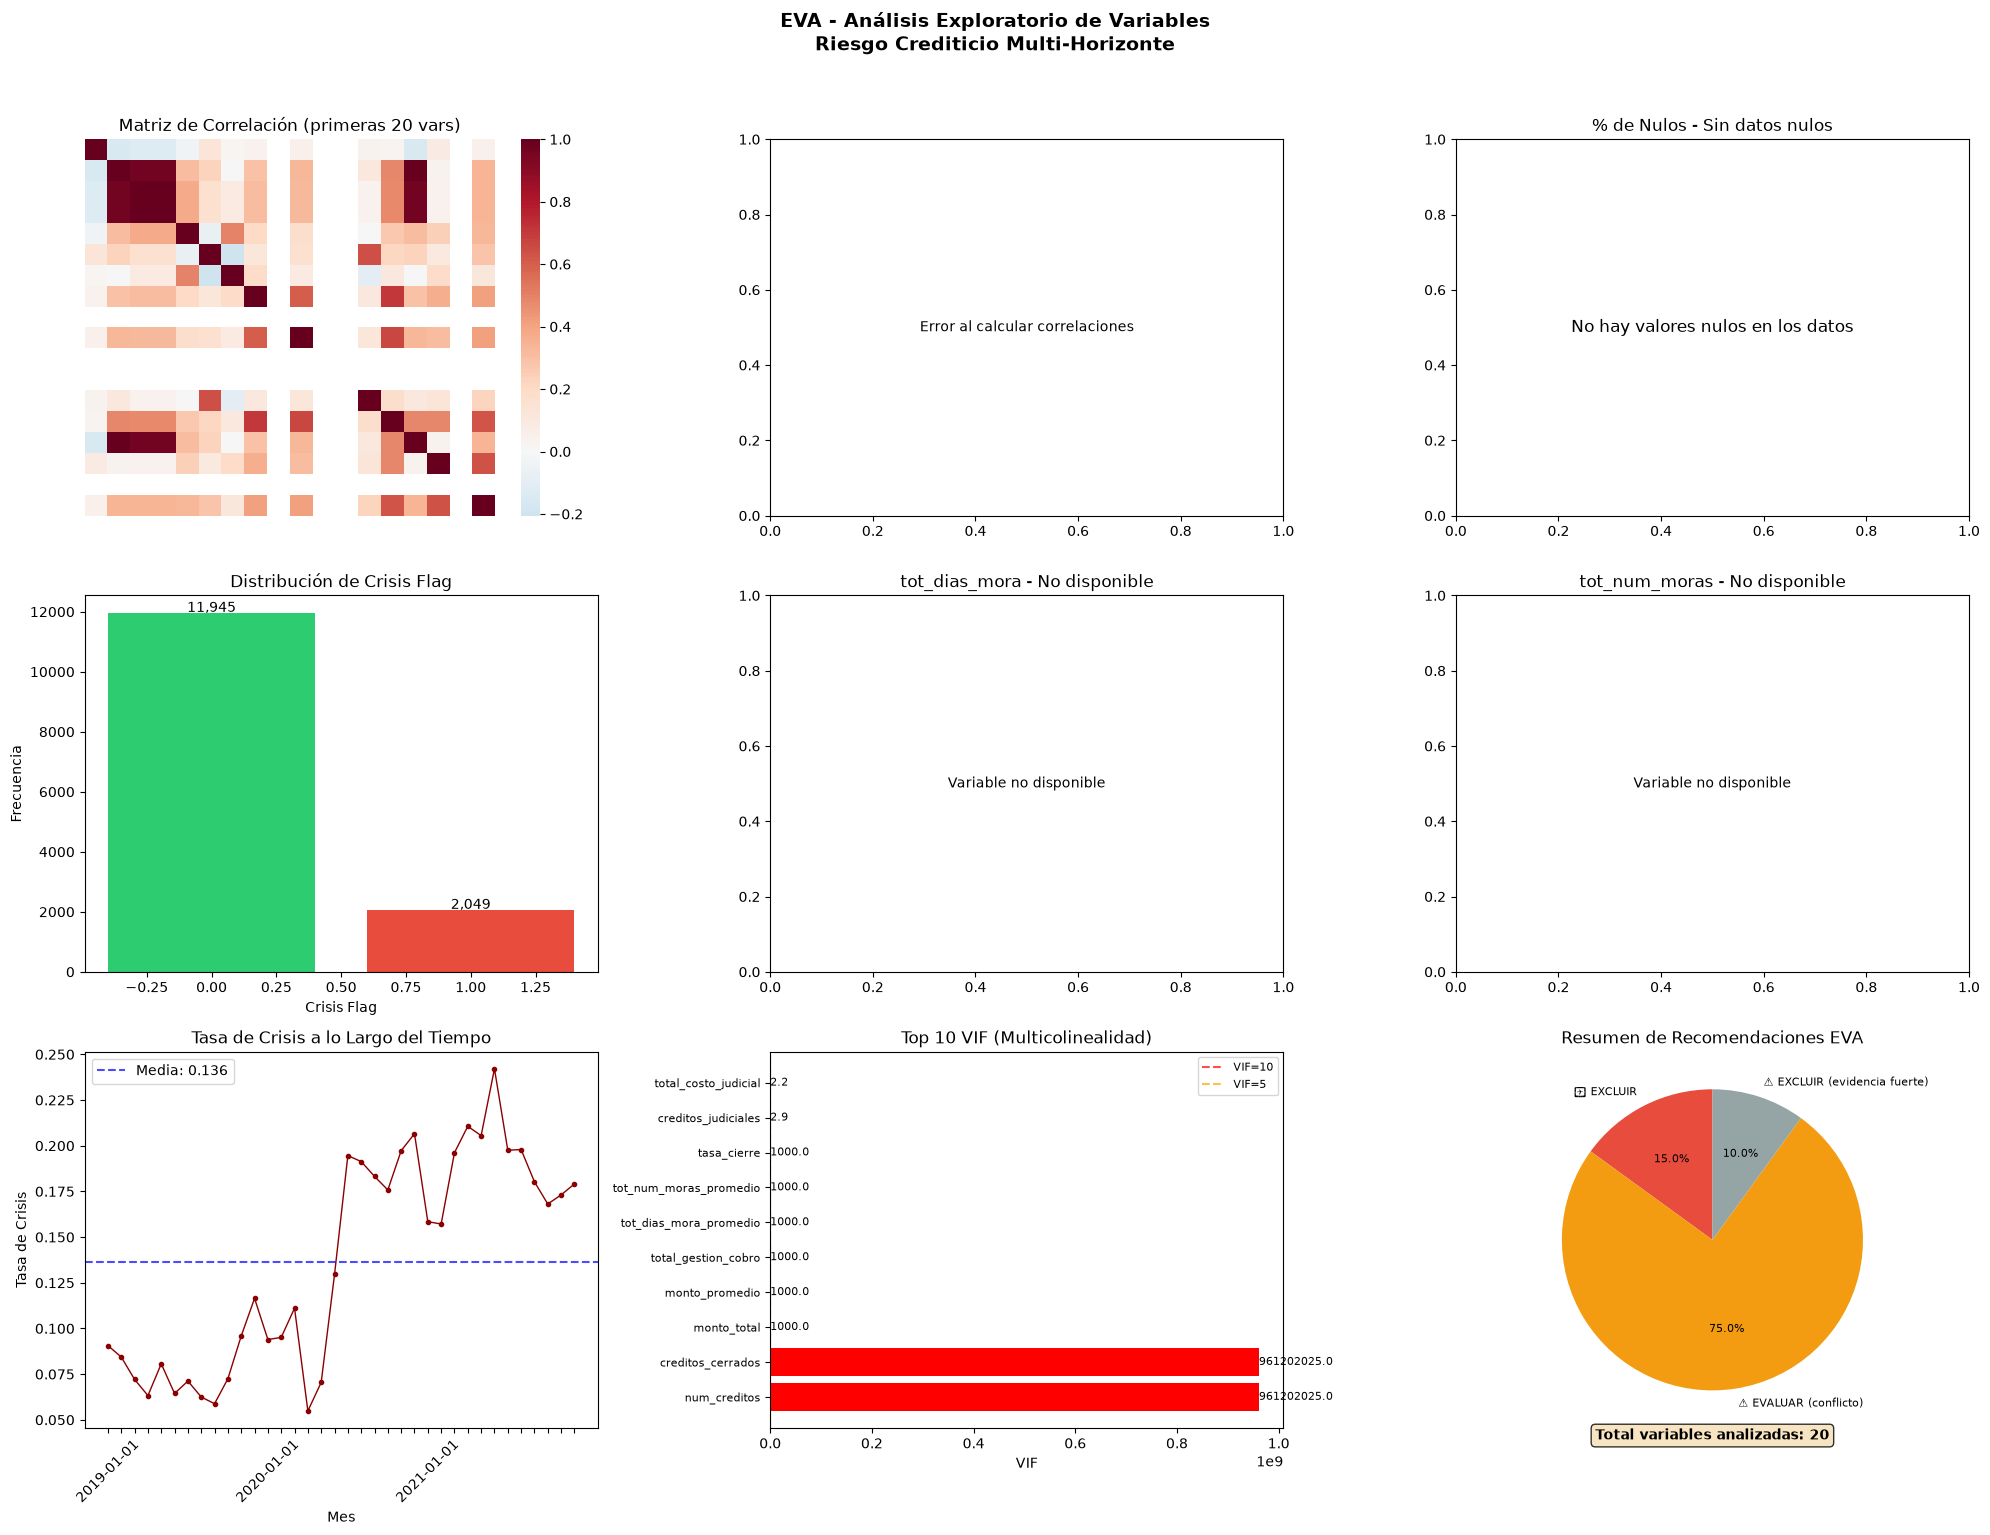

/home/ovelez/Documentos/cursos/Maestria/IADegreeThesis/Desarrollo/noteBooks/../src/eva/pipeline.py:909: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.savefig(png_path, dpi=150, bbox_inches="tight", facecolor="white")
2026-07-04 20:59:24,352 - INFO  - 📊 Dashboard guardado en: output/graficas/eda_completo.png
2026-07-04 20:59:24,361 - INFO  - 📋 Recomendaciones guardadas (20 vars) en: output/metricas/recomendaciones_eva.csv
2026-07-04 20:59:24,361 - INFO  - ✅ EVA COMPLETADO (modo notebook)
2026-07-04 20:59:24,361 - INFO  - 4) GUARDANDO ARTEFACTOS PARA MODELADO
2026-07-04 20:59:24,368 - INFO  - Artefactos generados:
2026-07-04 20:59:24,368 - INFO  - - output/datasets/datos_preprocesados.csv
2026-07-04 20:59:24,369 - INFO  - - output/metricas/recomendaciones_eva.csv
2026-07-04 20:59:24,369 - INFO  - - output/evidencia_eva/reporte_eva.json



PIPELINE EDA + EVA COMPLETADO
Artefactos generados:
1) output/datasets/datos_preprocesados.csv
2) output/metricas/recomendaciones_eva.csv
3) output/evidencia_eva/reporte_eva.json
--------------------------------------------------
CPU times: user 2min 59s, sys: 24.7 s, total: 3min 24s
Wall time: 3min 14s


In [11]:
%%time
print("ANALISIS EDA + EVA (OPTIMIZADO)")
print("-" * 50)
print("Autor: omar.velez@yachaytech.edu.ec")
print(f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"Rango: {ANIO_INICIO} - {ANIO_FIN}")
print("-" * 50)

df_features, recomendaciones = main_eva()

print("\nPIPELINE EDA + EVA COMPLETADO")
print("Artefactos generados:")
print("1) output/datasets/datos_preprocesados.csv")
print("2) output/metricas/recomendaciones_eva.csv")
print("3) output/evidencia_eva/reporte_eva.json")
print("-" * 50)

## Resumen de ejecucion (llenar en cada corrida)

- Fecha de ejecucion:
- Registros de entrada (df_raw):
- Registros de salida (df_features):
- Distribucion de crisis_flag:
- Alertas relevantes encontradas:
- Archivos generados:
  - output/datasets/datos_preprocesados.csv
  - output/metricas/recomendaciones_eva.csv
  - output/evidencia_eva/reporte_eva.json
- Proximo paso: ejecutar notebook de modelado usando el dataset generado.

![icon](../../DocumentosBase/yachayCuadrado.jpg)<br/>***<omar.velez@yachaytech.edu.ec>***<br/>*julio 2026*